In [4]:
from datasets import load_dataset

dataset = load_dataset("google/civil_comments")

c:\Users\USER\Downloads\Trending Project\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
train_data = dataset["train"].select(range(5000))

In [6]:
import pandas as pd

df = train_data.to_pandas()

In [6]:
df.head()

,text,toxicity,severe_toxicity,obscene,threat,insult,identity_attack,sexual_explicit
0,"This is so cool. It's like, 'would you want yo...",0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0
1,Thank you!! This would make my life a lot less...,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0
2,This is such an urgent design problem; kudos t...,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0
3,Is this something I'll be able to install on m...,0.000000,0.000000,0.0,0.0,0.00000,0.000000,0.0
4,haha you guys are a bunch of losers.,0.893617,0.021277,0.0,0.0,0.87234,0.021277,0.0


In [7]:
df.isnull().sum()

text               0
toxicity           0
severe_toxicity    0
obscene            0
threat             0
insult             0
identity_attack    0
sexual_explicit    0
dtype: int64

In [4]:
df = df.drop_duplicates(subset=["text"])

In [5]:
df = df.dropna(subset=["text"])

In [10]:
print(len(df))

4990


In [11]:
df["toxicity"].describe()

count    4990.000000
mean        0.069651
std         0.158987
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000
Name: toxicity, dtype: float64

In [13]:
df.columns

Index(['text', 'toxicity', 'severe_toxicity', 'obscene', 'threat', 'insult',
       'identity_attack', 'sexual_explicit'],
      dtype='str')

In [6]:
def aggression_level(score):
    if score < 0.30:
        return "Low"
    elif score < 0.70:
        return "Medium"
    else:
        return "High"


df["aggression_level"] = df["toxicity"].apply(aggression_level)

In [15]:
df[["text", "toxicity", "aggression_level"]].head(10)

,text,toxicity,aggression_level
0,"This is so cool. It's like, 'would you want yo...",0.000000,Low
1,Thank you!! This would make my life a lot less...,0.000000,Low
2,This is such an urgent design problem; kudos t...,0.000000,Low
3,Is this something I'll be able to install on m...,0.000000,Low
4,haha you guys are a bunch of losers.,0.893617,High
5,ur a sh*tty comment.,0.666667,Medium
6,hahahahahahahahhha suck it.,0.457627,Medium
7,FFFFUUUUUUUUUUUUUUU,0.000000,Low
8,The ranchers seem motivated by mostly by greed...,0.000000,Low
9,It was a great show. Not a combo I'd of expect...,0.000000,Low


In [16]:
df["aggression_level"].value_counts()

aggression_level
Low       4509
Medium     432
High        59
Name: count, dtype: int64

In [17]:
df["aggression_level"].value_counts(normalize=True) * 100

aggression_level
Low       90.18
Medium     8.64
High       1.18
Name: proportion, dtype: float64

Matplotlib is building the font cache; this may take a moment.


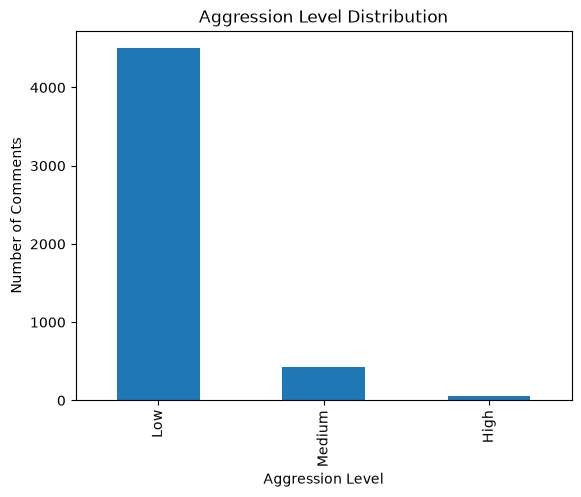

In [7]:
import matplotlib.pyplot as plt

df["aggression_level"].value_counts().plot(kind="bar")

plt.title("Aggression Level Distribution")
plt.xlabel("Aggression Level")
plt.ylabel("Number of Comments")
plt.show()

In [8]:
df.to_csv("../data/cleaned_civil_comments.csv", index=False)

In [9]:
from transformers import pipeline

toxicity_model = pipeline(
    "text-classification",
    model="unitary/toxic-bert"
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 2835.48it/s]


In [2]:
text = "You are completely useless."

result = toxicity_model(text)

print(result)

[{'label': 'toxic', 'score': 0.9163890480995178}]


In [3]:
text = "You are completely useless."

result = toxicity_model(text, top_k=None)

print(result)

[{'label': 'toxic', 'score': 0.9163890480995178}, {'label': 'insult', 'score': 0.576025664806366}, {'label': 'obscene', 'score': 0.045877840369939804}, {'label': 'identity_hate', 'score': 0.002793155610561371}, {'label': 'severe_toxic', 'score': 0.002344998996704817}, {'label': 'threat', 'score': 0.001567065599374473}]


In [4]:
for item in result:
    print(item["label"], ":", round(item["score"], 4))

toxic : 0.9164
insult : 0.576
obscene : 0.0459
identity_hate : 0.0028
severe_toxic : 0.0023
threat : 0.0016


In [5]:
text = "I really enjoyed reading this article."

result = toxicity_model(text, top_k=None)

for item in result:
    print(item["label"], ":", round(item["score"], 4))

toxic : 0.0006
obscene : 0.0002
insult : 0.0002
identity_hate : 0.0001
severe_toxic : 0.0001
threat : 0.0001


In [6]:
def predict_toxicity(text):
    results = toxicity_model(text, top_k=None)

    scores = {}

    for item in results:
        scores[item["label"]] = item["score"]

    return scores

In [7]:
predict_toxicity("You are completely useless.")

{'toxic': 0.9163890480995178,
 'insult': 0.576025664806366,
 'obscene': 0.045877840369939804,
 'identity_hate': 0.002793155610561371,
 'severe_toxic': 0.002344998996704817,
 'threat': 0.001567065599374473}

In [8]:
test_comments = [
    "I really enjoyed this article.",
    "I disagree with your opinion.",
    "You are completely useless.",
    "This is an interesting discussion.",
    "I hate you."
]

In [9]:
for comment in test_comments:
    print("\nComment:", comment)
    print(predict_toxicity(comment))


Comment: I really enjoyed this article.
{'toxic': 0.0005592403467744589, 'obscene': 0.00019677933596540242, 'insult': 0.0001744281908031553, 'identity_hate': 0.00014255032874643803, 'threat': 0.00013487272372003645, 'severe_toxic': 0.00013458238390740007}

Comment: I disagree with your opinion.
{'toxic': 0.0006798558752052486, 'obscene': 0.00017756015586201102, 'insult': 0.000175831577507779, 'identity_hate': 0.00015787537267897278, 'threat': 0.0001314865075983107, 'severe_toxic': 0.00012512149987742305}

Comment: You are completely useless.
{'toxic': 0.9163890480995178, 'insult': 0.576025664806366, 'obscene': 0.045877840369939804, 'identity_hate': 0.002793155610561371, 'severe_toxic': 0.002344998996704817, 'threat': 0.001567065599374473}

Comment: This is an interesting discussion.
{'toxic': 0.0005746950046159327, 'obscene': 0.0001988203584915027, 'insult': 0.0001791143586160615, 'identity_hate': 0.00014277547597885132, 'severe_toxic': 0.0001338771398877725, 'threat': 0.0001283137098

In [7]:
sample_df = df.head(100).copy()

In [15]:
sample_df["model_predictions"] = sample_df["text"].apply(
    predict_toxicity
)

In [16]:
sample_df[["text", "toxicity", "model_predictions"]].head()

,text,toxicity,model_predictions
0,"This is so cool. It's like, 'would you want yo...",0.000000,"{'toxic': 0.022374289110302925, 'insult': 0.00..."
1,Thank you!! This would make my life a lot less...,0.000000,"{'toxic': 0.003936603665351868, 'obscene': 0.0..."
2,This is such an urgent design problem; kudos t...,0.000000,"{'toxic': 0.0008505092700943351, 'obscene': 0...."
3,Is this something I'll be able to install on m...,0.000000,"{'toxic': 0.0007353292312473059, 'insult': 0.0..."
4,haha you guys are a bunch of losers.,0.893617,"{'toxic': 0.9672257900238037, 'insult': 0.8844..."


In [17]:
def get_toxic_score(text):
    scores = predict_toxicity(text)
    return scores["toxic"]

In [18]:
sample_df["model_toxicity"] = sample_df["text"].apply(
    get_toxic_score
)

In [19]:
sample_df[[
    "text",
    "toxicity",
    "model_toxicity"
]].head(10)

,text,toxicity,model_toxicity
0,"This is so cool. It's like, 'would you want yo...",0.000000,0.022374
1,Thank you!! This would make my life a lot less...,0.000000,0.003937
2,This is such an urgent design problem; kudos t...,0.000000,0.000851
3,Is this something I'll be able to install on m...,0.000000,0.000735
4,haha you guys are a bunch of losers.,0.893617,0.967226
5,ur a sh*tty comment.,0.666667,0.908656
6,hahahahahahahahhha suck it.,0.457627,0.994191
7,FFFFUUUUUUUUUUUUUUU,0.000000,0.637464
8,The ranchers seem motivated by mostly by greed...,0.000000,0.003383
9,It was a great show. Not a combo I'd of expect...,0.000000,0.000706


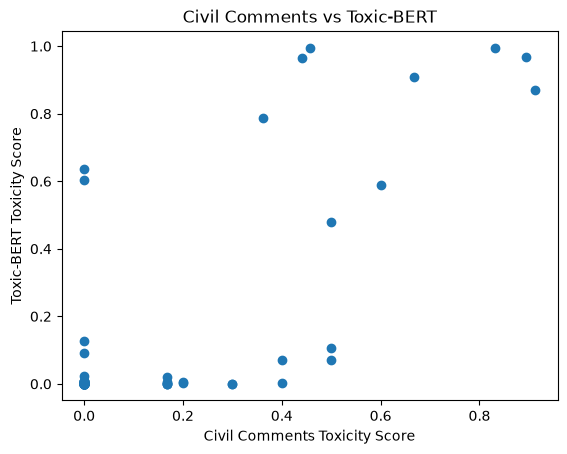

In [20]:
import matplotlib.pyplot as plt

plt.scatter(
    sample_df["toxicity"],
    sample_df["model_toxicity"]
)

plt.xlabel("Civil Comments Toxicity Score")
plt.ylabel("Toxic-BERT Toxicity Score")
plt.title("Civil Comments vs Toxic-BERT")
plt.show()

In [21]:
correlation = sample_df[
    ["toxicity", "model_toxicity"]
].corr().iloc[0, 1]

print("Correlation:", correlation)

Correlation: 0.7721687372865308


In [22]:
sample_df["aggression_score"] = sample_df["model_toxicity"]

In [23]:
def aggression_category(score):
    if score < 0.30:
        return "Low"
    elif score < 0.70:
        return "Medium"
    else:
        return "High"

In [24]:
sample_df["aggression_category"] = sample_df[
    "aggression_score"
].apply(aggression_category)

In [25]:
sample_df[[
    "text",
    "aggression_score",
    "aggression_category"
]].head(10)

,text,aggression_score,aggression_category
0,"This is so cool. It's like, 'would you want yo...",0.022374,Low
1,Thank you!! This would make my life a lot less...,0.003937,Low
2,This is such an urgent design problem; kudos t...,0.000851,Low
3,Is this something I'll be able to install on m...,0.000735,Low
4,haha you guys are a bunch of losers.,0.967226,High
5,ur a sh*tty comment.,0.908656,High
6,hahahahahahahahhha suck it.,0.994191,High
7,FFFFUUUUUUUUUUUUUUU,0.637464,Medium
8,The ranchers seem motivated by mostly by greed...,0.003383,Low
9,It was a great show. Not a combo I'd of expect...,0.000706,Low


In [26]:
sample_df["aggression_category"].value_counts()

aggression_category
Low       89
High       7
Medium     4
Name: count, dtype: int64

In [27]:
sample_df.to_csv(
    "../data/aggression_analysis_sample.csv",
    index=False
)

In [10]:
toxicity_model = pipeline(
    "text-classification",
    model="unitary/toxic-bert"
)

Loading weights: 100%|██████████| 201/201 [00:00<00:00, 1575.93it/s]


In [11]:
sample_df = df.head(100).copy()

In [12]:
def predict_toxicity(text):
    results = toxicity_model(text, top_k=None)

    scores = {}

    for item in results:
        scores[item["label"]] = item["score"]

    return scores

In [31]:
test_result = predict_toxicity(
    "You are completely useless."
)

print(test_result)

{'toxic': 0.9163890480995178, 'insult': 0.576025664806366, 'obscene': 0.045877840369939804, 'identity_hate': 0.002793155610561371, 'severe_toxic': 0.002344998996704817, 'threat': 0.001567065599374473}


In [32]:
sample_df["model_predictions"] = sample_df["text"].apply(
    predict_toxicity
)

In [33]:
sample_df[[
    "text",
    "toxicity",
    "model_predictions"
]].head()

,text,toxicity,model_predictions
0,"This is so cool. It's like, 'would you want yo...",0.000000,"{'toxic': 0.022374289110302925, 'insult': 0.00..."
1,Thank you!! This would make my life a lot less...,0.000000,"{'toxic': 0.003936603665351868, 'obscene': 0.0..."
2,This is such an urgent design problem; kudos t...,0.000000,"{'toxic': 0.0008505092700943351, 'obscene': 0...."
3,Is this something I'll be able to install on m...,0.000000,"{'toxic': 0.0007353292312473059, 'insult': 0.0..."
4,haha you guys are a bunch of losers.,0.893617,"{'toxic': 0.9672257900238037, 'insult': 0.8844..."


In [14]:
def get_toxic_score(text):
    scores = predict_toxicity(text)
    return scores["toxic"]

In [15]:
sample_df["model_toxicity"] = sample_df["text"].apply(
    get_toxic_score
)

In [36]:
sample_df[[
    "text",
    "toxicity",
    "model_toxicity"
]].head(10)

,text,toxicity,model_toxicity
0,"This is so cool. It's like, 'would you want yo...",0.000000,0.022374
1,Thank you!! This would make my life a lot less...,0.000000,0.003937
2,This is such an urgent design problem; kudos t...,0.000000,0.000851
3,Is this something I'll be able to install on m...,0.000000,0.000735
4,haha you guys are a bunch of losers.,0.893617,0.967226
5,ur a sh*tty comment.,0.666667,0.908656
6,hahahahahahahahhha suck it.,0.457627,0.994191
7,FFFFUUUUUUUUUUUUUUU,0.000000,0.637464
8,The ranchers seem motivated by mostly by greed...,0.000000,0.003383
9,It was a great show. Not a combo I'd of expect...,0.000000,0.000706


In [37]:
correlation = sample_df[
    ["toxicity", "model_toxicity"]
].corr().iloc[0, 1]

print("Correlation:", correlation)

Correlation: 0.7721687372865308


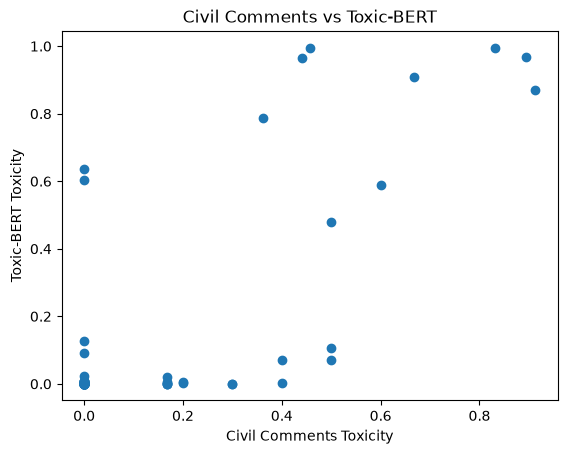

In [38]:
import matplotlib.pyplot as plt

plt.scatter(
    sample_df["toxicity"],
    sample_df["model_toxicity"]
)

plt.xlabel("Civil Comments Toxicity")
plt.ylabel("Toxic-BERT Toxicity")
plt.title("Civil Comments vs Toxic-BERT")
plt.show()

In [16]:
sample_df["true_toxic"] = (
    sample_df["toxicity"] >= 0.5
).astype(int)

In [17]:
sample_df["predicted_toxic"] = (
    sample_df["model_toxicity"] >= 0.5
).astype(int)

In [2]:
import numpy as np


def confusion_matrix(y_true, y_pred):
    labels = np.unique(np.concatenate((np.asarray(y_true), np.asarray(y_pred))))
    matrix = np.zeros((len(labels), len(labels)), dtype=int)
    for actual, predicted in zip(y_true, y_pred):
        actual_index = np.where(labels == actual)[0][0]
        predicted_index = np.where(labels == predicted)[0][0]
        matrix[actual_index, predicted_index] += 1
    return matrix


def accuracy_score(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return float(np.mean(y_true == y_pred))


def precision_score(y_true, y_pred, zero_division=0):
    matrix = confusion_matrix(y_true, y_pred)
    true_positives = matrix[-1, -1]
    predicted_positives = matrix[:, -1].sum()
    return float(true_positives / predicted_positives) if predicted_positives else zero_division


def recall_score(y_true, y_pred, zero_division=0):
    matrix = confusion_matrix(y_true, y_pred)
    true_positives = matrix[-1, -1]
    actual_positives = matrix[-1, :].sum()
    return float(true_positives / actual_positives) if actual_positives else zero_division


def f1_score(y_true, y_pred, zero_division=0):
    precision = precision_score(y_true, y_pred, zero_division=zero_division)
    recall = recall_score(y_true, y_pred, zero_division=zero_division)
    return float(2 * precision * recall / (precision + recall)) if precision + recall else zero_division

In [18]:
y_true = sample_df["true_toxic"]
y_pred = sample_df["predicted_toxic"]

In [19]:
accuracy = accuracy_score(y_true, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.92


In [20]:
precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

print("Precision:", precision)

Precision: 0.5


In [21]:
recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

print("Recall:", recall)

Recall: 0.625


In [22]:
f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

print("F1 Score:", f1)

F1 Score: 0.5555555555555556


In [23]:
cm = confusion_matrix(y_true, y_pred)

print(cm)

[[87  5]
 [ 3  5]]


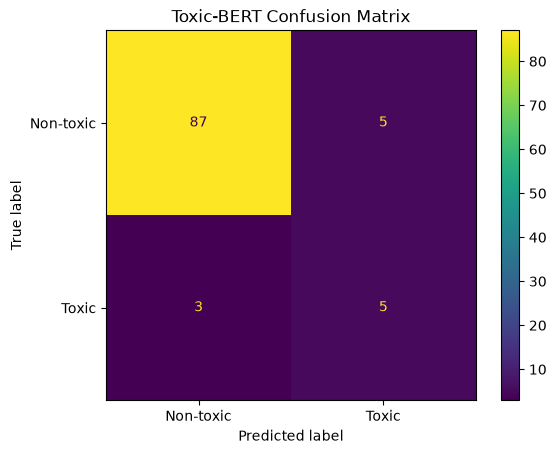

In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-toxic", "Toxic"]
).plot()

plt.title("Toxic-BERT Confusion Matrix")
plt.show()

In [26]:
validation_data = dataset["validation"].select(range(1000))

validation_df = validation_data.to_pandas()

In [27]:
validation_df = validation_df.dropna(subset=["text"])
validation_df = validation_df.drop_duplicates(subset=["text"])

In [28]:
validation_df.to_csv(
    "../data/toxicity_validation_results.csv",
    index=False
)

In [29]:
print("Validation comments:", len(validation_df))

Validation comments: 1000


In [30]:
def get_toxic_score(text):
    scores = predict_toxicity(text)
    return scores["toxic"]

In [31]:
validation_df["model_toxicity"] = validation_df["text"].apply(
    get_toxic_score
)

In [32]:
validation_df["true_toxic"] = (
    validation_df["toxicity"] >= 0.5
).astype(int)

validation_df["predicted_toxic"] = (
    validation_df["model_toxicity"] >= 0.5
).astype(int)

In [33]:
y_true = validation_df["true_toxic"]
y_pred = validation_df["predicted_toxic"]

print("Accuracy :", accuracy_score(y_true, y_pred))
print("Precision:", precision_score(y_true, y_pred, zero_division=0))
print("Recall   :", recall_score(y_true, y_pred, zero_division=0))
print("F1 Score :", f1_score(y_true, y_pred, zero_division=0))

Accuracy : 0.95
Precision: 0.6739130434782609
Recall   : 0.4696969696969697
F1 Score : 0.5535714285714286


In [34]:
validation_df.to_csv(
    "../data/toxicity_validation_results.csv",
    index=False
)